In [3]:
import scarf
import h5py
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
scarf.__version__

'0.32.3'

In [3]:

reader = scarf.H5adReader(
    h5ad_fn="Basal Forebrain - Septal Nuclei.h5ad",
    cell_ids_key="CellID",          
    feature_ids_key="_index",        
    feature_name_key="feature_name", 
    matrix_key="X",                     
)

writer = scarf.H5adToZarr(
    reader,
    zarr_loc='BF_septal_nuclei.zarr',
    chunk_size=(2000,1000)
)
writer.dump()



INFO: No value provided for assay names. Will use default value: 'RNA'


Reading attributes from group obs:   0%|                                                                      …

Reading attributes from group obsm:   0%|                                                                     …

Reading attributes from group var:   0%|                                                                      …

  0%|                                                                                                         …

In [5]:
ds = scarf.DataStore(
    'BF_septal_nuclei.zarr', # same loco as where you saved the zarr
    nthreads=4,
    min_features_per_cell = 10 
)


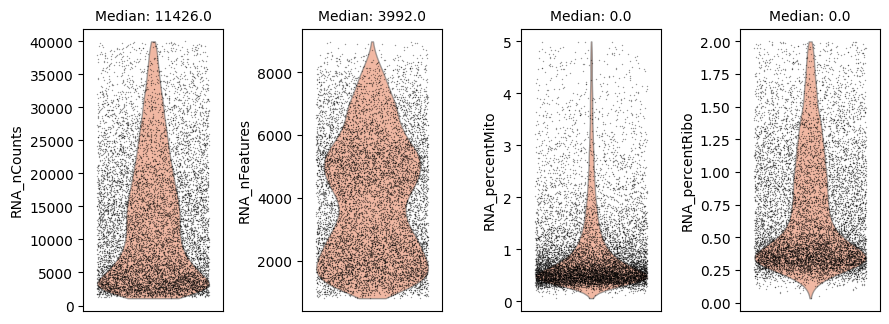

In [10]:
ds.plot_cells_dists(cell_key='I', color='coral') # just to show some qc metrics

In [8]:
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures'],
    highs=[50000, 9000],
    lows=[1000, 500]
)
## since the external segment of the globus pallidus appears to be so weird... I think I will likely do an stringent upper threshold and lower threshold. Not sure if its becuase their is UMI
## duplicates or thats the actual single nucleus morphology here

INFO: 467 cells flagged for filtering out using attribute RNA_nCounts
INFO: 449 cells flagged for filtering out using attribute RNA_nFeatures


In [9]:
ds # filters out roughly 700 cells

DataStore has 36043 (40815) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_UMAP1', 'RNA_UMAP2', 
            'RNA_cluster', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 
            'RNA_percentRibo', 'X_UMAP1', 'X_UMAP2', 'X_tSNE1', 'X_tSNE2', 
            'cell_cycle_score', 'fraction_mitochondrial', 'fraction_unspliced', 'is_primary_data', 'observation_joinid', 
            'total_UMIs', 'total_genes'
   RNA assay has 33480 (58232) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'dropOuts', 
            'feature_is_filtered', 'nCells'

INFO: Calculating summary statistics


(RNA) Computing nCells:   0%|                                                                                 …

(RNA) Computing normed_tot:   0%|                                                                             …

(RNA) Computing sigmas:   0%|                                                                                 …

INFO: Calculating HVGs
INFO: 1995 genes marked as HVGs


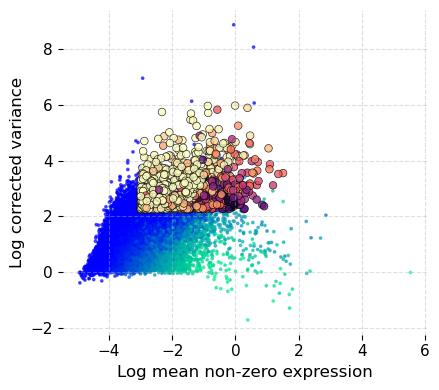

In [10]:
ds.mark_hvgs(
    min_cells=20, # genes found in at least 20 of the cells
    top_n=2000, # means the top 2k highly variable genes
    min_mean=-3,
    max_mean=2,
    max_var=6
)

In [11]:
ds.make_graph(
    feat_key='hvgs',
    k=11,
    dims=30, ## dims is about the of PCA dimensions
    n_centroids=100
)

Normalizing with feature subset:   0%|                                                                        …

Writing data to normed__I__hvgs/data:   0%|                                                                   …

Calculating mean of norm. data:   0%|                                                                         …

Calculating std. dev. of norm. data:   0%|                                                                    …

Fitting PCA:   0%|                                                                                            …

...

Fitting kmeans:   0%|                                                                                         …

Estimating seed partitions:   0%|                                                                             …

Identifying neighbors:   0%|                                                                                  …

Smoothening KNN distances:   0%|                                                                              …

INFO: ANN recall: 99.50%


In [12]:
ds.run_umap(
    n_epochs = 250,
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP:   0%|                                                                                          …

	completed  0  /  250 epochs
	completed  25  /  250 epochs
	completed  50  /  250 epochs
	completed  75  /  250 epochs
	completed  100  /  250 epochs
	completed  125  /  250 epochs
	completed  150  /  250 epochs
	completed  175  /  250 epochs
	completed  200  /  250 epochs
	completed  225  /  250 epochs


/opt/anaconda3/lib/python3.12/site-packages/scarf/metadata.py:334: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)
/opt/anaconda3/lib/python3.12/site-packages/scarf/metadata.py:334: RuntimeWarning: invalid value encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [13]:
ds.cells.head() # making sure UMAP was acc made

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo,X_UMAP1,X_UMAP2,X_tSNE1,X_tSNE2,cell_cycle_score,fraction_mitochondrial,fraction_unspliced,is_primary_data,observation_joinid,total_UMIs,total_genes
0,True,10X377_6:ATAGGCTAGGCACAAC,10X377_6:ATAGGCTAGGCACAAC,-12.955248,-7.944401,2572.0,1581.0,1.594090,2.099533,12.084384,7.944125,-12.072369,13.422815,0.001163,0.013178,0.469380,True,k9fTQDaE)q,2580.0,1588.0
1,True,10X191_1:CATTCCGGTACAAGCG,10X191_1:CATTCCGGTACAAGCG,-12.912867,-9.869537,3207.0,1731.0,4.240723,1.091363,9.803556,14.861278,-7.182784,-22.989905,0.001245,0.037648,0.670193,True,TQgZNw+oZ2,3214.0,1738.0
2,True,10X330_3:GTGTTCCTCGGTCTGG,10X330_3:GTGTTCCTCGGTCTGG,-15.770295,-9.335174,2531.0,1496.0,0.790202,1.422363,0.455407,13.042712,-2.673647,6.019888,0.002758,0.007092,0.695823,True,Q1=V9Zlx#E,2538.0,1502.0
3,True,10X330_3:CGGGCATTCATCGTAG,10X330_3:CGGGCATTCATCGTAG,-15.006791,-10.392344,4691.0,2323.0,0.703475,0.703475,0.464096,13.106882,-2.661863,6.034367,0.001276,0.000213,0.798682,True,PP|5}x7Pwf,4704.0,2329.0
4,True,10X377_5:CTGTGAAGTGGGTTGA,10X377_5:CTGTGAAGTGGGTTGA,-13.879192,-11.987339,5804.0,3148.0,0.499655,1.395589,7.958884,10.574122,-30.394712,25.499492,0.001372,0.000857,0.584119,True,Nrgky2q<mu,5831.0,3163.0


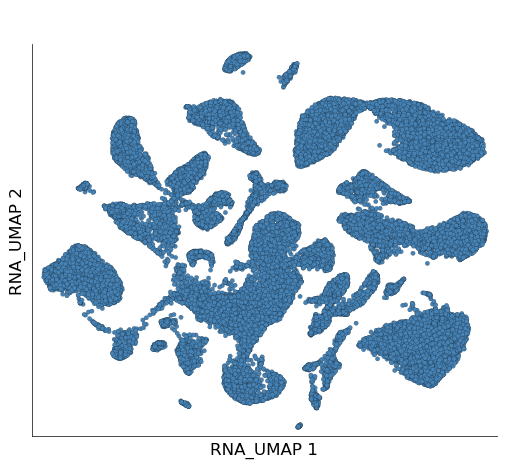

In [14]:
ds.plot_layout(layout_key='RNA_UMAP')

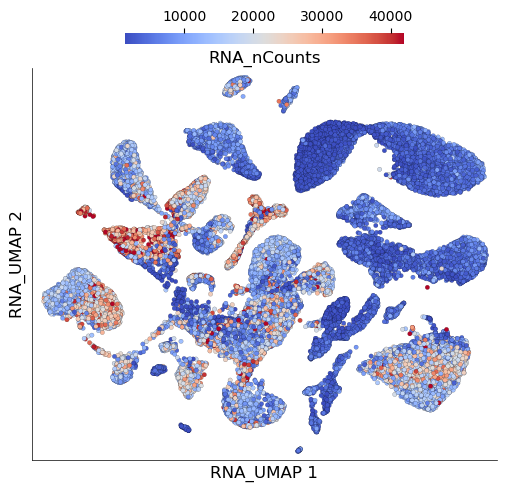

In [15]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
    cmap='coolwarm' # visualize data from each column
)

In [25]:
ds.run_leiden_clustering(resolution=1.1) # closer to 0 resolution means less clusters, closer to 1 means more clusters

/opt/anaconda3/lib/python3.12/site-packages/scarf/metadata.py:334: RuntimeWarning: invalid value encountered in cast
  a = np.empty(self.N).astype(values.dtype)


/opt/anaconda3/lib/python3.12/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


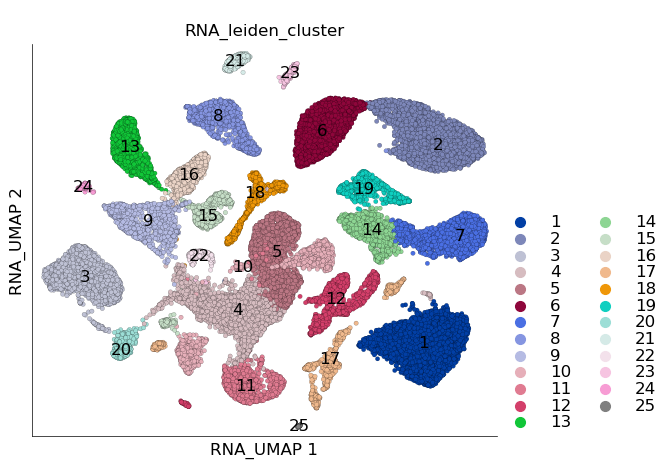

In [18]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)
#savename=None, save_dpi=300
#res = 0.65 here